In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

import os
import re

import sklearn
import sklearn.model_selection
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import tensorflow as tf

# Use keras 2
import tf_keras as tfk
os.environ["TF_USE_LEGACY_KERAS"] ="1"

## Use keras 3
#tfk = tf.keras

from normalizing_flow import MAF

In [2]:
os.environ["CUDA_VISIBLE_DEVICES"]="0"

In [3]:
flist = np.loadtxt('data/flist', dtype=str)
flist_lemmas = []
for f in flist:
    f=f.replace('_bis', '')
    f=f.replace('_ter', '')
    f=f.replace('Nt8_', '8 ')
    f=f.replace('NF8_', '')
    f=f.replace('ferm_Ns', '')
    f=f.replace('b', '')
    f=f.replace('M0p', '0.')
    f=f.replace('_', ' ')
    lemmas = f.split()
    lemmas = [lemmas[3], lemmas[2], lemmas[0], lemmas[1]]
    flist_lemmas = flist_lemmas + [lemmas]

In [4]:
def extract_vars(l):
    beta = float(l[0])
    m = float(l[1])
    ns = float(l[2])
    nt = float(l[3])
    return beta, m, ns, nt

In [5]:
flist[0]

'ferm_Ns12_Nt8_NF8_M0p0085_b2.2550'

In [6]:
flist_lemmas[0]

['2.2550', '0.0085', '12', '8']

In [7]:
extract_vars(flist_lemmas[0])

(2.255, 0.0085, 12.0, 8.0)

In [8]:
therm = 400
each = 1

plaq = np.loadtxt('data/'+flist[0])[therm::each,2]
ff = np.loadtxt('data/'+flist[0])[therm::each,4]
(beta, m, ns, nt) = extract_vars(flist_lemmas[0])
M = plaq
M = np.vstack([M, ff])
M = np.vstack([M, beta*np.ones(plaq.size)])
M = np.vstack([M, m*np.ones(plaq.size)])
M = np.vstack([M, ns*np.ones(plaq.size)])

for i in np.arange(1,flist.size):
    plaq = np.loadtxt('data/'+flist[i])[therm::each,2]
    ff = np.loadtxt('data/'+flist[i])[therm::each,4]
    (beta, m, ns, nt) = extract_vars(flist_lemmas[i])
    N = plaq
    N = np.vstack([N, ff])
    N = np.vstack([N, beta*np.ones(plaq.size)])
    N = np.vstack([N, m*np.ones(plaq.size)])
    N = np.vstack([N, ns*np.ones(plaq.size)])
    M = np.hstack([M, N])
M = M.transpose()

In [9]:
M.shape

(2507411, 5)

In [10]:
M[0:3]

array([[3.00146807e-01, 1.00105486e+00, 2.25500000e+00, 8.50000000e-03,
        1.20000000e+01],
       [3.00146807e-01, 1.16423067e+00, 2.25500000e+00, 8.50000000e-03,
        1.20000000e+01],
       [3.00146807e-01, 1.05576065e+00, 2.25500000e+00, 8.50000000e-03,
        1.20000000e+01]])

In [11]:
np.argwhere(np.isnan(M))

array([], shape=(0, 2), dtype=int64)

In [12]:
x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(M, np.ones(M.shape[0]))

In [13]:
scaler=MinMaxScaler()
scaler.fit_transform(x_train)
x_train=scaler.transform(x_train)
x_test=scaler.transform(x_test)

In [14]:
nvars = 2 # plaq, ff
ncondvars = 3 # beta, m, ns (NO nt)

nflow = MAF(nvars, ncondvars, nblocks=12, hidden_units=[64, 64], activation='relu', last_activation='relu', l1=0.0, l2=1.0e-4)

#print(nflow.trainable_variables)

nflow.compile(optimizer=tfk.optimizers.Adam(learning_rate=1.0e-3), loss=lambda _, log_prob: -log_prob)

2025-10-23 15:54:18.226165: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 37644 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:25:00.0, compute capability: 8.0


In [15]:
batch_size = 32768
#batch_size = 65536
history = nflow.fit(x=[x_train[:,:nvars], x_train[:,nvars:nvars+ncondvars]],
          y=np.zeros((x_train.shape[0], 0), dtype=np.float32),
          batch_size=batch_size,
          epochs=500,
          steps_per_epoch=x_train.shape[0] // batch_size,
          shuffle=True,
          verbose=True,
          validation_data=([x_test[:,:nvars], x_test[:,nvars:nvars+ncondvars]],np.zeros((x_test.shape[0], 0), dtype=np.float32)),
          callbacks=[tfk.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=30, restore_best_weights=True)])


Epoch 1/500


2025-10-23 15:54:41.542787: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7efe98751830 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-23 15:54:41.542847: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB, Compute Capability 8.0
2025-10-23 15:54:41.547988: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-23 15:54:41.563845: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2025-10-23 15:54:41.646331: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


57/57 [==============================] - 32s 74ms/step - loss: 0.0377 - val_loss: -1.1046
Epoch 2/500
57/57 [==============================] - 2s 38ms/step - loss: -2.3592 - val_loss: -3.1957
Epoch 3/500
57/57 [==============================] - 2s 38ms/step - loss: -3.4420 - val_loss: -3.5223
Epoch 4/500
57/57 [==============================] - 2s 38ms/step - loss: -3.5503 - val_loss: -3.5919
Epoch 5/500
57/57 [==============================] - 2s 38ms/step - loss: -3.6100 - val_loss: -3.6668
Epoch 6/500
57/57 [==============================] - 2s 36ms/step - loss: -3.5857 - val_loss: -3.2610
Epoch 7/500
57/57 [==============================] - 2s 37ms/step - loss: -3.6267 - val_loss: -3.7380
Epoch 8/500
57/57 [==============================] - 2s 38ms/step - loss: -3.7980 - val_loss: -3.8715
Epoch 9/500
57/57 [==============================] - 2s 38ms/step - loss: -3.8976 - val_loss: -3.9309
Epoch 10/500
57/57 [==============================] - 2s 38ms/step - loss: -3.9637 - val_loss:

57/57 [==============================] - 2s 38ms/step - loss: -4.4765 - val_loss: -4.5063
Epoch 81/500
57/57 [==============================] - 2s 37ms/step - loss: -4.4883 - val_loss: -4.4880
Epoch 82/500
57/57 [==============================] - 2s 38ms/step - loss: -4.4898 - val_loss: -4.5107
Epoch 83/500
57/57 [==============================] - 2s 36ms/step - loss: -4.4863 - val_loss: -4.4883
Epoch 84/500
57/57 [==============================] - 2s 36ms/step - loss: -4.4909 - val_loss: -4.4947
Epoch 85/500
57/57 [==============================] - 2s 36ms/step - loss: -4.4872 - val_loss: -4.4733
Epoch 86/500
57/57 [==============================] - 2s 36ms/step - loss: -4.4872 - val_loss: -4.4708
Epoch 87/500
57/57 [==============================] - 2s 36ms/step - loss: -4.5035 - val_loss: -4.4907
Epoch 88/500
57/57 [==============================] - 2s 38ms/step - loss: -4.5012 - val_loss: -4.5327
Epoch 89/500
57/57 [==============================] - 2s 38ms/step - loss: -4.5211 - v

57/57 [==============================] - 2s 37ms/step - loss: -4.6019 - val_loss: -4.5421
Epoch 160/500
57/57 [==============================] - 2s 39ms/step - loss: -4.6040 - val_loss: -4.6211
Epoch 161/500
57/57 [==============================] - 2s 38ms/step - loss: -4.6103 - val_loss: -4.6100
Epoch 162/500
57/57 [==============================] - 2s 40ms/step - loss: -4.6051 - val_loss: -4.6164
Epoch 163/500
57/57 [==============================] - 2s 40ms/step - loss: -4.6048 - val_loss: -4.6284
Epoch 164/500
57/57 [==============================] - 2s 38ms/step - loss: -4.6021 - val_loss: -4.5977
Epoch 165/500
57/57 [==============================] - 2s 38ms/step - loss: -4.6197 - val_loss: -4.6294
Epoch 166/500
57/57 [==============================] - 2s 37ms/step - loss: -4.5950 - val_loss: -4.6115
Epoch 167/500
57/57 [==============================] - 2s 39ms/step - loss: -4.6075 - val_loss: -4.6337
Epoch 168/500
57/57 [==============================] - 2s 36ms/step - loss: -4

Epoch 238/500
57/57 [==============================] - 2s 39ms/step - loss: -4.6561 - val_loss: -4.6747
Epoch 239/500
57/57 [==============================] - 2s 39ms/step - loss: -4.6574 - val_loss: -4.6813
Epoch 240/500
57/57 [==============================] - 2s 40ms/step - loss: -4.6709 - val_loss: -4.6748
Epoch 241/500
57/57 [==============================] - 2s 37ms/step - loss: -4.6630 - val_loss: -4.6347
Epoch 242/500
57/57 [==============================] - 2s 36ms/step - loss: -4.6627 - val_loss: -4.6705
Epoch 243/500
57/57 [==============================] - 2s 39ms/step - loss: -4.6688 - val_loss: -4.6838
Epoch 244/500
57/57 [==============================] - 2s 39ms/step - loss: -4.6647 - val_loss: -4.6865
Epoch 245/500
57/57 [==============================] - 2s 37ms/step - loss: -4.6620 - val_loss: -4.6809
Epoch 246/500
57/57 [==============================] - 2s 38ms/step - loss: -4.6630 - val_loss: -4.6647
Epoch 247/500
57/57 [==============================] - 2s 38ms/s

Epoch 317/500
57/57 [==============================] - 2s 39ms/step - loss: -4.6944 - val_loss: -4.6888
Epoch 318/500
57/57 [==============================] - 2s 40ms/step - loss: -4.7010 - val_loss: -4.7142
Epoch 319/500
57/57 [==============================] - 2s 38ms/step - loss: -4.6937 - val_loss: -4.7099
Epoch 320/500
57/57 [==============================] - 2s 38ms/step - loss: -4.6977 - val_loss: -4.6990
Epoch 321/500
57/57 [==============================] - 2s 39ms/step - loss: -4.6913 - val_loss: -4.6701
Epoch 322/500
57/57 [==============================] - 2s 39ms/step - loss: -4.7005 - val_loss: -4.7160
Epoch 323/500
57/57 [==============================] - 2s 38ms/step - loss: -4.6910 - val_loss: -4.6606
Epoch 324/500
57/57 [==============================] - 2s 40ms/step - loss: -4.6995 - val_loss: -4.7142
Epoch 325/500
57/57 [==============================] - 2s 38ms/step - loss: -4.6945 - val_loss: -4.6840
Epoch 326/500
57/57 [==============================] - 2s 39ms/s

Epoch 396/500
57/57 [==============================] - 2s 37ms/step - loss: -4.7031 - val_loss: -4.7201
Epoch 397/500
57/57 [==============================] - 2s 39ms/step - loss: -4.7066 - val_loss: -4.7187
Epoch 398/500
57/57 [==============================] - 2s 40ms/step - loss: -4.7158 - val_loss: -4.7272
Epoch 399/500
57/57 [==============================] - 2s 41ms/step - loss: -4.7187 - val_loss: -4.7284
Epoch 400/500
57/57 [==============================] - 2s 37ms/step - loss: -4.7131 - val_loss: -4.7170
Epoch 401/500
57/57 [==============================] - 2s 39ms/step - loss: -4.7041 - val_loss: -4.7290
Epoch 402/500
57/57 [==============================] - 2s 37ms/step - loss: -4.7058 - val_loss: -4.7015
Epoch 403/500
57/57 [==============================] - 2s 37ms/step - loss: -4.7193 - val_loss: -4.7286
Epoch 404/500
57/57 [==============================] - 2s 37ms/step - loss: -4.7066 - val_loss: -4.7143
Epoch 405/500
57/57 [==============================] - 2s 36ms/s

Epoch 475/500
57/57 [==============================] - 2s 37ms/step - loss: -4.7213 - val_loss: -4.7282
Epoch 476/500
57/57 [==============================] - 2s 38ms/step - loss: -4.7137 - val_loss: -4.7241
Epoch 477/500
57/57 [==============================] - 2s 39ms/step - loss: -4.7107 - val_loss: -4.7332
Epoch 478/500
57/57 [==============================] - 2s 41ms/step - loss: -4.7227 - val_loss: -4.7362
Epoch 479/500
57/57 [==============================] - 2s 39ms/step - loss: -4.7326 - val_loss: -4.7347
Epoch 480/500
57/57 [==============================] - 2s 38ms/step - loss: -4.7151 - val_loss: -4.6944
Epoch 481/500
57/57 [==============================] - 2s 39ms/step - loss: -4.7122 - val_loss: -4.7301
Epoch 482/500
57/57 [==============================] - 2s 37ms/step - loss: -4.7228 - val_loss: -4.7217
Epoch 483/500
57/57 [==============================] - 2s 37ms/step - loss: -4.7225 - val_loss: -4.6916
Epoch 484/500
57/57 [==============================] - 2s 39ms/s

(-8.0, 2.0)

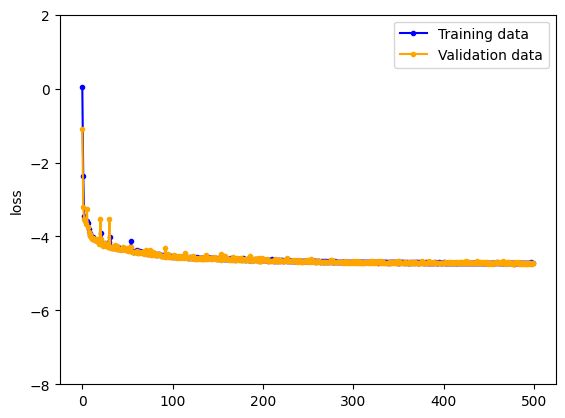

In [16]:
plt.plot(history.history['loss'], ls='-', marker='.', color='blue', label='Training data')
plt.plot(history.history['val_loss'], ls='-', marker='.', color='orange', label='Validation data')
plt.legend()
plt.ylabel('loss')
plt.ylim(-8,2)

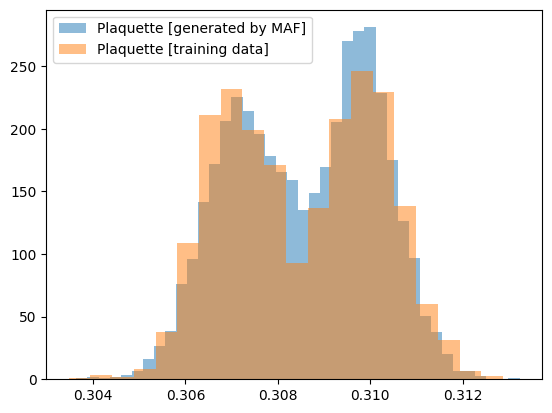

In [17]:
nsamples = 10000

cond = scaler.transform(np.array([[0.0, 0.0, 2.2950, 0.01, 16]]))[0][2:]
samples = nflow.sample(cond, nsamples)
h = np.vstack([samples[:,0], samples[:,1]])
h = np.vstack([h, np.zeros((3,nsamples))])
h = h.transpose()
unscaled_samples = scaler.inverse_transform(h)[:,0]
plt.hist(unscaled_samples, 40, alpha=0.5, density=True, label='Plaquette [generated by MAF]');

unscaled_x_train = scaler.inverse_transform(x_train)
plt.hist(unscaled_x_train[(unscaled_x_train[:,2] == 2.2950) & (unscaled_x_train[:,3] == 0.01)  & (unscaled_x_train[:,4] == 16)][:,0], 20, alpha=0.5, density=True, label='Plaquette [training data]');

plt.legend()

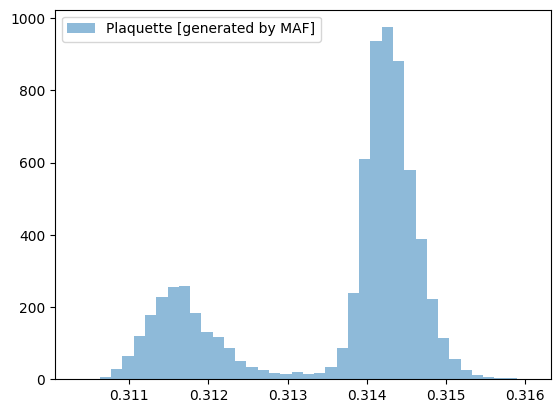

In [18]:
# mass = 0.01125 not in training data

nsamples = 10000

cond = scaler.transform(np.array([[0.0, 0.0, 2.3215, 0.01125, 32]]))[0][2:]
samples = nflow.sample(cond, nsamples)
h = np.vstack([samples[:,0], samples[:,1]])
h = np.vstack([h, np.zeros((3,nsamples))])
h = h.transpose()
unscaled_samples = scaler.inverse_transform(h)[:,0]
plt.hist(unscaled_samples, 40, alpha=0.5, density=True, label='Plaquette [generated by MAF]');

plt.legend()

In [19]:
def calc_obs(beta, m, ns, nsamples=10000):

    cond = scaler.transform(np.array([[0.0, 0.0, beta, m, ns]]))[0][2:]
    samples = nflow.sample(cond, nsamples)
    h = np.vstack([samples[:,0], samples[:,1]])
    h = np.vstack([h, np.zeros((3,nsamples))])
    h = h.transpose()
    myplaq = scaler.inverse_transform(h)[:,0]
    myff = scaler.inverse_transform(h)[:,1]
    
    return (np.mean(myplaq), np.std(myplaq)/np.sqrt(nsamples), np.mean(myff), np.std(myff)/np.sqrt(nsamples))

Text(0, 0.5, '$<Plaquette>$')

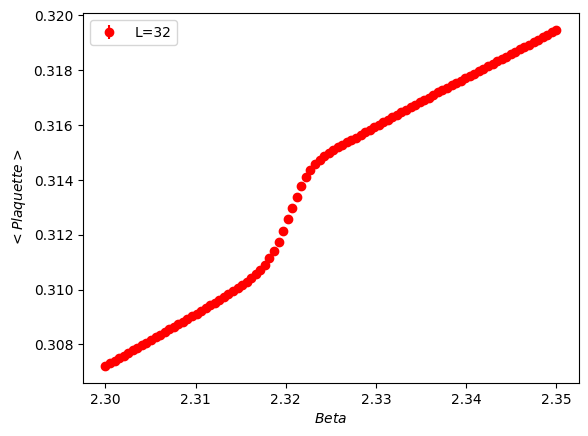

In [20]:
mybeta = np.linspace(2.300, 2.350, 100)

mym = 0.01125
myns = 32

myplaq32 = np.array([])
dmyplaq32 = np.array([])
myff32 = np.array([])
dmyff32 = np.array([])

for x in mybeta:
    (a,b,c,d) = calc_obs(x, mym, myns, nsamples=10000)
    myplaq32 = np.append(myplaq32, a)
    dmyplaq32 = np.append(dmyplaq32, b)
    myff32 = np.append(myff32, c)
    dmyff32 = np.append(dmyff32, d)

plt.errorbar(mybeta, myplaq32, dmyplaq32, linestyle='', marker='o', color='red', label='L=32')
plt.legend()
plt.xlabel('$Beta$')
plt.ylabel('$<Plaquette>$')